In [119]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt

In [120]:
SEED = 42
ACTIVE_STAGE = "stage05"

# Setting the folds once
#   [None]        -> the frozen split in valRegions.csv 
#   [0, 1, 2, 3]  -> the spatial folds from scripts/makeFolds.py --k 4 --rows 2
FOLDS = [0, 1, 2, 3]

# --- patch extraction ---
PATCH_SIZE = 256
STRIDE = 128            # 50% overlap, so the split must be spatial (see mt-split)
LOW_THRESHOLD = 0.001   # below this a patch is 'negative'
HIGH_THRESHOLD = 0.05   # at or above this a patch is 'positive'

# --- augmentation ---
AUGMENT_FACTOR = 3      # 1 original + 3 fixed transformed copies, materialised once

# --- training ---
EPOCHS = 100
BATCH_SIZE = 4
WEIGHT = 2.0            # foreground up-weight inside the BCE term
TVERSKY_ALPHA = 0.5     # weights false negatives
TVERSKY_BETA = 0.5      # weights false positives; alpha = beta = 0.5 is Dice
EARLY_STOPPING_PATIENCE = 15
USE_BATCHNORM = True

IMAGE_PATH = "../data/processed/images/ngc628Norm.npy"
MASK_PATH = "../data/processed/masks/ngc628NormMask.npy"
IGNORE_MASK_PATH = "../data/processed/masks/ngc628IgnoreMask.npy"
MODEL_DIR = Path("../outputs/models")
OUTPUT_DIR = Path("../outputs")
HISTORY_DIR = Path("../outputs/history")
PLOTS_DIR = "../outputs/figures/plots"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

def fold_paths(fold):
    """Every path that depends on the fold, in one place.

    fold=None keeps the original locations so this notebook is a drop-in
    replacement for the three it consolidates.
    """
    if fold is None:
        return {
            "val_regions": "../data/processed/metadata/valRegions.csv",
            "patch_dir": "../data/processed/patches",
            "aug_dir": "../data/processed/augmented",
            "tag": ACTIVE_STAGE,
        }
    return {
        "val_regions": f"../data/processed/metadata/folds/fold{fold}/valRegions.csv",
        "patch_dir": f"../data/processed/patches/fold{fold}",
        "aug_dir": f"../data/processed/augmented/fold{fold}",
        "tag": f"{ACTIVE_STAGE}fold{fold}",
    }


print(f"ACTIVE_STAGE={ACTIVE_STAGE}  FOLDS={FOLDS}")
for f in FOLDS:
    print(f"  fold {f}: tag={fold_paths(f)['tag']}, regions={fold_paths(f)['val_regions']}")

ACTIVE_STAGE=stage05  FOLDS=[0, 1, 2, 3]
  fold 0: tag=stage05fold0, regions=../data/processed/metadata/folds/fold0/valRegions.csv
  fold 1: tag=stage05fold1, regions=../data/processed/metadata/folds/fold1/valRegions.csv
  fold 2: tag=stage05fold2, regions=../data/processed/metadata/folds/fold2/valRegions.csv
  fold 3: tag=stage05fold3, regions=../data/processed/metadata/folds/fold3/valRegions.csv


In [121]:
image = np.load(IMAGE_PATH).astype(np.float32)
mask = np.load(MASK_PATH).astype(np.float32)

if os.path.exists(IGNORE_MASK_PATH):
    ignore = np.load(IGNORE_MASK_PATH).astype(np.float32)
    USING_IGNORE_LABELS = True
else:
    ignore = np.zeros_like(mask)
    USING_IGNORE_LABELS = False
    print("No ignore mask - every pixel supervised. Re-run galaxyMaskGeneration.ipynb.\n")

assert image.shape == mask.shape == ignore.shape, "image, mask and ignore disagree on shape"
assert image.ndim == 2, "Expected image to be a 2D array."
assert not ((mask > 0.5) & (ignore > 0.5)).any(), (
    "a pixel is both positive and ignored - regenerate the masks"
)

print("Image:", image.shape, image.dtype, image.min(), image.max())
print(f"Mask foreground : {mask.mean():.4f}")
print(f"Ignored region  : {ignore.mean():.4f}   (ignore labels active: {USING_IGNORE_LABELS})")

Image: (1177, 2380) float32 0.0 1.0
Mask foreground : 0.1846
Ignored region  : 0.0000   (ignore labels active: True)


In [122]:
# --- patch extraction ---------------------------------

def extract_patches(image, mask, ignore, patch_size=PATCH_SIZE, stride=STRIDE,
                    low_threshold=LOW_THRESHOLD, high_threshold=HIGH_THRESHOLD):
    H, W = image.shape
    pos_patches, weak_patches, neg_patches = [], [], []

    for y_start in range(0, H - patch_size + 1, stride):
        for x_start in range(0, W - patch_size + 1, stride):
            image_patch = image[y_start:y_start + patch_size, x_start:x_start + patch_size]
            mask_patch = mask[y_start:y_start + patch_size, x_start:x_start + patch_size]
            ignore_patch = ignore[y_start:y_start + patch_size, x_start:x_start + patch_size]

            # weight = 1 where the loss should look, 0 where it should not
            weight_patch = (1.0 - ignore_patch).astype(np.float32)

            # bubble_ratio stays the raw positive fraction, so the positive /
            # weak / negative thresholds keep the meaning they had before
            # ignore labels existed
            bubble_ratio = mask_patch.mean()

            record = {
                "image": image_patch,
                "mask": mask_patch,
                "weight": weight_patch,
                "y_start": y_start,
                "x_start": x_start,
                "bubble_ratio": bubble_ratio,
                "ignore_ratio": float(ignore_patch.mean()),
            }

            if bubble_ratio >= high_threshold:
                record["category"] = "positive"
                pos_patches.append(record)
            elif bubble_ratio >= low_threshold:
                record["category"] = "weak"
                weak_patches.append(record)
            else:
                record["category"] = "negative"
                neg_patches.append(record)

    return pos_patches, weak_patches, neg_patches

In [123]:
# --- spatial hold-out + class balancing ---------------
def build_dataset(pos, weak, neg, val_regions_path, seed=SEED):
    val_regions = pd.read_csv(val_regions_path)

    def assign_split(y, x, patch_size=PATCH_SIZE):
        for _, region in val_regions.iterrows():
            y0, x0 = region.y_start, region.x_start
            y1, x1 = y0 + region.height, x0 + region.width
            if y >= y0 and y + patch_size <= y1 and x >= x0 and x + patch_size <= x1:
                return "val"        # fully inside an exam region
            if not (y + patch_size <= y0 or y >= y1 or x + patch_size <= x0 or x >= x1):
                return "excluded"   # straddles an exam boundary: used by neither side
        return "train"

    rng = np.random.RandomState(seed)

    for record in pos + weak + neg:
        record["split"] = assign_split(record["y_start"], record["x_start"])

    # balancing applies to the training pool only; every val patch is kept
    pos_train = [r for r in pos if r["split"] == "train"]
    weak_train = [r for r in weak if r["split"] == "train"]
    neg_train = [r for r in neg if r["split"] == "train"]

    rng.shuffle(weak_train)
    rng.shuffle(neg_train)

    n_positive = len(pos_train)
    n_weak = min(len(weak_train), n_positive)
    n_neg = min(len(neg_train), n_positive // 2)

    val_patches = [r for r in pos + weak + neg if r["split"] == "val"]
    dataset = pos_train + weak_train[:n_weak] + neg_train[:n_neg] + val_patches
    rng.shuffle(dataset)

    n_excluded = sum(r["split"] == "excluded" for r in pos + weak + neg)
    return dataset, len(val_patches), n_excluded


def stack_arrays(dataset):
    X = np.array([r["image"] for r in dataset], dtype=np.float32)[..., np.newaxis]
    Y = np.array([r["mask"] for r in dataset], dtype=np.float32)[..., np.newaxis]
    W = np.array([r["weight"] for r in dataset], dtype=np.float32)[..., np.newaxis]

    metadata = pd.DataFrame([
        {
            "patch_id": i,
            "y_start": r["y_start"],
            "x_start": r["x_start"],
            "category": r["category"],
            "bubble_ratio": r["bubble_ratio"],
            "ignore_ratio": r["ignore_ratio"],
            "split": r["split"],
        }
        for i, r in enumerate(dataset)
    ])

    assert X.shape == Y.shape == W.shape and X.ndim == 4
    assert len(metadata) == len(X)
    return X, Y, W, metadata

In [124]:
# --- augmentation -----------------------
def paired_augmentation(image, mask, weight=None, seed=None):
    if seed is None:
        seed = SEED

    image = tf.convert_to_tensor(image, dtype=tf.float32)
    mask = tf.convert_to_tensor(mask, dtype=tf.float32)
    weight = tf.ones_like(mask) if weight is None else tf.convert_to_tensor(weight, tf.float32)

    combined = tf.concat([image, mask, weight], axis=-1)
    combined = tf.image.stateless_random_flip_left_right(combined, seed=[seed, 1])
    combined = tf.image.stateless_random_flip_up_down(combined, seed=[seed, 2])
    rotation_k = tf.random.stateless_uniform(
        shape=[], seed=[seed, 3], minval=0, maxval=4, dtype=tf.int32
    )
    combined = tf.image.rot90(combined, k=rotation_k)

    return (
        combined[..., :1],
        tf.cast(combined[..., 1:2] >= 0.5, tf.float32),
        tf.cast(combined[..., 2:3] >= 0.5, tf.float32),
    )


def paired_augmentation_with_intensity(image, mask, weight=None, seed=None):
    if seed is None:
        seed = SEED

    image, mask, weight = paired_augmentation(image, mask, weight, seed=seed)
    image = tf.image.stateless_random_brightness(image, max_delta=0.08, seed=[seed, 4])
    image = tf.image.stateless_random_contrast(image, lower=0.9, upper=1.1, seed=[seed, 5])
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, mask, weight


def augment_dataset(X_train, Y_train, W_train, augment_factor=AUGMENT_FACTOR, seed=SEED):
    X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
    Y_train = tf.convert_to_tensor(Y_train, dtype=tf.float32)
    W_train = tf.convert_to_tensor(W_train, dtype=tf.float32)

    image_batches, mask_batches, weight_batches = [X_train], [Y_train], [W_train]

    for augmentation_index in range(augment_factor):
        imgs, msks, wts = [], [], []
        for patch_index in range(len(X_train)):
            sample_seed = seed + (augmentation_index + 1) * 100_000 + patch_index
            i, m, w = paired_augmentation_with_intensity(
                X_train[patch_index], Y_train[patch_index], W_train[patch_index],
                seed=sample_seed,
            )
            imgs.append(i); msks.append(m); wts.append(w)
        image_batches.append(tf.stack(imgs))
        mask_batches.append(tf.stack(msks))
        weight_batches.append(tf.stack(wts))

    return (
        tf.concat(image_batches, axis=0).numpy(),
        tf.concat(mask_batches, axis=0).numpy(),
        tf.concat(weight_batches, axis=0).numpy(),
    )


def check_augmentation(X, Y, W, n=5):
    """Geometry sync, binarity, and area preservation across image/mask/weight."""
    for index in range(min(n, len(X))):
        for repeat in range(5):
            seed = SEED + index * 100 + repeat
            ai, am, aw = paired_augmentation_with_intensity(X[index], Y[index], W[index], seed=seed)
            si, sm, sw = paired_augmentation(Y[index], Y[index], Y[index], seed=seed)

            assert float(tf.reduce_sum(am)) == float(tf.reduce_sum(Y[index])), "foreground area changed"
            assert float(tf.reduce_sum(aw)) == float(tf.reduce_sum(W[index])), "supervised area changed"
            assert np.all(np.isin(np.unique(am.numpy()), [0.0, 1.0])), "mask not binary"
            assert np.all(np.isin(np.unique(aw.numpy()), [0.0, 1.0])), "weight not binary"
            assert np.array_equal(si.numpy(), sm.numpy()), "image/mask geometry desynced"
            assert np.array_equal(sm.numpy(), sw.numpy()), "mask/weight geometry desynced"
            assert float(tf.reduce_sum(am * (1.0 - aw))) == 0.0, "a positive pixel is ignored"
            assert 0.0 <= float(tf.reduce_min(ai)) and float(tf.reduce_max(ai)) <= 1.0, "image left [0,1]"
    print("augmentation invariants passed")

In [125]:
# --- model, losses, metrics --------------------------

def conv_block(x, filters, use_batchnorm=None):
    """Two 3x3 convs, each optionally batch-normalised before its activation."""
    if use_batchnorm is None:
        use_batchnorm = USE_BATCHNORM
    for _ in range(2):
        x = layers.Conv2D(filters, 3, padding="same",
                          activation=None if use_batchnorm else "relu")(x)
        if use_batchnorm:
            x = layers.BatchNormalization()(x)
            x = layers.Activation("relu")(x)
    return x


def build_unet(input_shape=(PATCH_SIZE, PATCH_SIZE, 1)):
    inputs = layers.Input(input_shape)

    c1 = conv_block(inputs, 16); p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 32);     p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 64);     p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 128);    p4 = layers.MaxPooling2D()(c4)

    b1 = conv_block(p4, 256)     # bottleneck, 16x16

    u4 = layers.concatenate([layers.UpSampling2D()(b1), c4]); d4 = conv_block(u4, 128)
    u3 = layers.concatenate([layers.UpSampling2D()(d4), c3]); d3 = conv_block(u3, 64)
    u2 = layers.concatenate([layers.UpSampling2D()(d3), c2]); d2 = conv_block(u2, 32)
    u1 = layers.concatenate([layers.UpSampling2D()(d2), c1]); d1 = conv_block(u1, 16)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d1)
    return models.Model(inputs, outputs, name="bubble_unet4")

def unpack(y_true):
    if y_true.shape[-1] == 2:
        return y_true[..., :1], y_true[..., 1:2]
    return y_true, tf.ones_like(y_true)


def tversky_loss(y_true, y_pred, smooth=1, alpha=None, beta=None):
    """Tversky index, masked. alpha weights false negatives, beta false positives.

    Written on Dice's scale - numerator 2*TP, denominator 2*TP + 2a*FN + 2b*FP -
    rather than the textbook TP / (TP + a*FN + b*FP). The two are identical
    without smoothing, but the textbook denominator is half Dice's, so adding the
    same `smooth` to both would put the constant on a different scale and
    Tversky(0.5, 0.5) would MISS Dice by ~2e-4. On this form the identity
    2*TP + FN + FP == sum(y) + sum(p) makes it exact, and alpha = beta = 1 still
    gives Jaccard. The self-check cell below asserts it.
    """
    alpha = TVERSKY_ALPHA if alpha is None else alpha
    beta = TVERSKY_BETA if beta is None else beta

    y_t, w = unpack(y_true)
    y_t = tf.reshape(y_t, [-1]); w = tf.reshape(w, [-1]); y_p = tf.reshape(y_pred, [-1])

    true_pos = tf.reduce_sum(w * y_t * y_p)
    false_neg = tf.reduce_sum(w * y_t * (1 - y_p))
    false_pos = tf.reduce_sum(w * (1 - y_t) * y_p)

    return 1 - (2 * true_pos + smooth) / (
        2 * true_pos + 2 * alpha * false_neg + 2 * beta * false_pos + smooth
    )


def weighted_bce(y_true, y_pred):
    y_t, w = unpack(y_true)
    y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())
    weights = y_t * WEIGHT + 1
    bce = tf.keras.backend.binary_crossentropy(y_t, y_pred)
    # mean over SUPERVISED pixels only
    return tf.reduce_sum(w * weights * bce) / (tf.reduce_sum(w) + 1e-7)


def combined_loss(y_true, y_pred):
    return weighted_bce(y_true, y_pred) + tversky_loss(y_true, y_pred)


def dice_coef(y_true, y_pred, smooth=1):
    y_t, w = unpack(y_true)
    y_t = tf.reshape(y_t, [-1]); w = tf.reshape(w, [-1]); y_p = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(w * y_t * y_p)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(w * y_t) + tf.reduce_sum(w * y_p) + smooth
    )


def iou_coef(y_true, y_pred, smooth=1):
    y_t, w = unpack(y_true)
    y_t = tf.reshape(y_t, [-1]); w = tf.reshape(w, [-1]); y_p = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(w * y_t * y_p)
    union = tf.reduce_sum(w * y_t) + tf.reduce_sum(w * y_p) - intersection
    return (intersection + smooth) / (union + smooth)

In [126]:
# masked forms must reproduce the unmasked ones on all-ones weights, and
# Tversky at alpha = beta = 0.5 must be exactly Dice
_rng = np.random.default_rng(0)
_y = tf.constant(_rng.integers(0, 2, (2, 32, 32, 1)), dtype=tf.float32)
_w = tf.ones_like(_y)
_p = tf.constant(_rng.random((2, 32, 32, 1)), dtype=tf.float32)
_packed = tf.concat([_y, _w], axis=-1)

assert abs(float(dice_coef(_packed, _p)) - float(dice_coef(_y, _p))) < 1e-5, \
    "masked dice disagrees with unmasked dice on all-ones weights"
assert abs(float(tversky_loss(_packed, _p, alpha=0.5, beta=0.5))
           - float(1 - dice_coef(_packed, _p))) < 1e-5, \
    "Tversky at alpha=beta=0.5 is not Dice"

# and a half-ignored target must score differently from a fully supervised one
_w_half = tf.concat([tf.ones_like(_y[:, :16]), tf.zeros_like(_y[:, 16:])], axis=1)
assert abs(float(dice_coef(tf.concat([_y, _w_half], -1), _p))
           - float(dice_coef(_packed, _p))) > 1e-6, "masking has no effect"

print("masked loss/metric self-check passed")

masked loss/metric self-check passed


In [127]:
def run_fold(fold):
    """Patches -> split -> augment -> train -> save, for one fold."""
    paths = fold_paths(fold)
    tag = paths["tag"]
    os.makedirs(paths["patch_dir"], exist_ok=True)
    os.makedirs(paths["aug_dir"], exist_ok=True)

    print(f"\n{'=' * 70}\nFOLD {fold}   tag={tag}\n{'=' * 70}")

    # reset per fold so fold k does not inherit fold k-1's RNG state
    tf.keras.utils.set_random_seed(SEED)

    # --- patches ---
    pos, weak, neg = extract_patches(image, mask, ignore)
    dataset, n_val, n_excluded = build_dataset(pos, weak, neg, paths["val_regions"])
    X, Y, W, metadata = stack_arrays(dataset)

    train_idx = metadata.index[metadata["split"] == "train"].to_numpy()
    val_idx = metadata.index[metadata["split"] == "val"].to_numpy()

    print(f"patches: {len(dataset)} (train {len(train_idx)}, val {len(val_idx)}, "
          f"{n_excluded} excluded at exam boundaries)")
    assert len(val_idx) > 0, f"fold {fold} has no validation patches - check the fold layout"

    metadata.to_csv(os.path.join(paths["patch_dir"], "patchMetadata.csv"), index=False)
    np.save(os.path.join(paths["patch_dir"], "X.npy"), X)
    np.save(os.path.join(paths["patch_dir"], "Y.npy"), Y)
    np.save(os.path.join(paths["patch_dir"], "W.npy"), W)

    # --- augment ---
    X_train, Y_train, W_train = X[train_idx], Y[train_idx], W[train_idx]
    X_val, Y_val, W_val = X[val_idx], Y[val_idx], W[val_idx]

    X_train_aug, Y_train_aug, W_train_aug = augment_dataset(X_train, Y_train, W_train)
    print(f"augmented train: {X_train_aug.shape[0]} patches "
          f"({AUGMENT_FACTOR + 1} fixed views of each of {len(train_idx)})")

    for name, arr in [("XtrainAug", X_train_aug), ("YtrainAug", Y_train_aug),
                      ("WtrainAug", W_train_aug), ("Xval", X_val),
                      ("Yval", Y_val), ("Wval", W_val)]:
        np.save(os.path.join(paths["aug_dir"], f"{name}.npy"), np.asarray(arr, np.float32))

    # --- train ---
    YW_train = np.concatenate([Y_train_aug, W_train_aug], axis=-1)
    YW_val = np.concatenate([Y_val, W_val], axis=-1)

    model = build_unet()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=combined_loss,
        metrics=[dice_coef, iou_coef],
    )

    best_weights = os.path.join(MODEL_DIR, f"{tag}bubble_unet_best.weights.h5")
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(str(best_weights), monitor="val_dice_coef",
                                           mode="max", save_best_only=True,
                                           save_weights_only=True, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor="val_dice_coef", mode="max",
                                         patience=EARLY_STOPPING_PATIENCE,
                                         restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.5,
                                             patience=6, min_lr=1e-6, verbose=0),
        tf.keras.callbacks.CSVLogger(str(HISTORY_DIR /  f"{tag}training_history.csv")),
    ]

    history = model.fit(
        X_train_aug, YW_train,
        validation_data=(X_val, YW_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True,
        callbacks=callbacks, verbose=2,
    )
    model.load_weights(best_weights)

    # --- threshold sweep, over supervised pixels only ---
    preds_val = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0)

    def dice_at(t):
        b = (preds_val > t).astype(np.float32)
        inter = np.sum(W_val * Y_val * b)
        return (2 * inter + 1) / (np.sum(W_val * Y_val) + np.sum(W_val * b) + 1)

    sweep = [(float(t), float(dice_at(t)),
              float((W_val * (preds_val > t)).sum() / W_val.sum()))
             for t in np.arange(0.05, 0.951, 0.025)]
    best_threshold, best_dice, best_fg = max(sweep, key=lambda r: r[1])

    # --- save ---
    model_path = os.path.join(MODEL_DIR, f"{tag}bubble_unet.keras")
    model.save(model_path)

    with open(HISTORY_DIR / f"{tag}training_history.json", "w") as fh:
        json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, fh, indent=2)

    run_config = {
        "active_stage": ACTIVE_STAGE, "fold": fold,
        "use_batchnorm": USE_BATCHNORM,
        "tversky_alpha": TVERSKY_ALPHA, "tversky_beta": TVERSKY_BETA,
        "bce_weight": WEIGHT, "ignore_labels": USING_IGNORE_LABELS,
        "augment_factor": AUGMENT_FACTOR, "epochs": EPOCHS, "batch_size": BATCH_SIZE,
        "seed": SEED, "params": int(model.count_params()),
        "n_train_patches": int(len(train_idx)), "n_val_patches": int(len(val_idx)),
        "n_excluded_patches": int(n_excluded),
        "train_supervised_ratio": float(W_train_aug.mean()),
        "val_supervised_ratio": float(W_val.mean()),
    }
    with open(HISTORY_DIR / f"{tag}runConfig.json", "w") as fh:
        json.dump(run_config, fh, indent=2)

    threshold_summary = {
        "active_stage": ACTIVE_STAGE, "fold": fold,
        "best_threshold": best_threshold, "validation_dice": best_dice,
        "predicted_foreground_ratio": best_fg,
        "ground_truth_foreground_ratio": float((Y_val * W_val).sum() / W_val.sum()),
        "supervised_ratio": float(W_val.mean()), "masked": bool(USING_IGNORE_LABELS),
    }
    with open(HISTORY_DIR / f"{tag}threshold_summary.json", "w") as fh:
        json.dump(threshold_summary, fh, indent=2)

    best_epoch = int(np.argmax(history.history["val_dice_coef"]))
    result = {
        "fold": fold, "tag": tag,
        "n_train": len(train_idx), "n_val": len(val_idx), "n_excluded": n_excluded,
        "epochs_run": len(history.history["loss"]), "best_epoch": best_epoch,
        "val_dice_soft": float(history.history["val_dice_coef"][best_epoch]),
        "train_dice_soft": float(history.history["dice_coef"][best_epoch]),
        "best_threshold": best_threshold, "val_dice_hard": best_dice,
        "pred_foreground": best_fg,
    }
    result["train_val_gap"] = result["train_dice_soft"] - result["val_dice_soft"]

    print(f"\nfold {fold}: best epoch {best_epoch}, val dice {best_dice:.4f} "
          f"at t={best_threshold:.3f}, gap {result['train_val_gap']:.4f}")
    print("saved:", model_path)

    return result, history

In [128]:
# one-off invariant check on a real patch before committing to a long run
_pos, _weak, _neg = extract_patches(image, mask, ignore)
_ds, _, _ = build_dataset(_pos, _weak, _neg, fold_paths(FOLDS[0])["val_regions"])
_X, _Y, _W, _ = stack_arrays(_ds)
check_augmentation(_X, _Y, _W)
del _pos, _weak, _neg, _ds, _X, _Y, _W

results, histories = [], {}
for fold in FOLDS:
    result, history = run_fold(fold)
    results.append(result)
    histories[fold] = history

results_df = pd.DataFrame(results)
print("\n" + "=" * 70)
print(results_df.to_string(index=False, float_format="%.4f"))

augmentation invariants passed

FOLD 0   tag=stage05fold0
patches: 110 (train 86, val 24, 26 excluded at exam boundaries)
augmented train: 344 patches (4 fixed views of each of 86)
Epoch 1/100
86/86 - 46s - 538ms/step - dice_coef: 0.3261 - iou_coef: 0.1964 - loss: 1.6726 - val_dice_coef: 0.2053 - val_iou_coef: 0.1155 - val_loss: 1.6356 - learning_rate: 1.0000e-04
Epoch 2/100
86/86 - 34s - 400ms/step - dice_coef: 0.3798 - iou_coef: 0.2363 - loss: 1.5305 - val_dice_coef: 0.1759 - val_iou_coef: 0.0971 - val_loss: 1.6963 - learning_rate: 1.0000e-04
Epoch 3/100
86/86 - 34s - 394ms/step - dice_coef: 0.4081 - iou_coef: 0.2586 - loss: 1.4568 - val_dice_coef: 0.1492 - val_iou_coef: 0.0812 - val_loss: 1.8137 - learning_rate: 1.0000e-04
Epoch 4/100
86/86 - 34s - 395ms/step - dice_coef: 0.4330 - iou_coef: 0.2790 - loss: 1.3896 - val_dice_coef: 0.1465 - val_iou_coef: 0.0796 - val_loss: 1.8279 - learning_rate: 1.0000e-04
Epoch 5/100
86/86 - 34s - 395ms/step - dice_coef: 0.4630 - iou_coef: 0.3045 - l

In [129]:
summary_path = HISTORY_DIR / f"{ACTIVE_STAGE}foldSummary.csv"
results_df.to_csv(summary_path, index=False)

if len(results_df) > 1:
    metrics = ["val_dice_hard", "val_dice_soft", "best_threshold",
               "pred_foreground", "train_val_gap"]
    agg = results_df[metrics].agg(["mean", "std", "min", "max"]).T
    print(f"across {len(results_df)} folds:\n")
    print(agg.to_string(float_format="%.4f"))
    print(f"\nval dice = {agg.loc['val_dice_hard', 'mean']:.4f} "
          f"+/- {agg.loc['val_dice_hard', 'std']:.4f} (spread across folds)")
else:
    print("single run - set FOLDS = [0, 1, 2, 3] for a spread")

print("\nwrote", summary_path)

across 4 folds:

                  mean    std    min    max
val_dice_hard   0.4733 0.0615 0.4021 0.5424
val_dice_soft   0.4209 0.0582 0.3429 0.4675
best_threshold  0.4250 0.1369 0.2750 0.6000
pred_foreground 0.3559 0.1083 0.2243 0.4646
train_val_gap   0.1987 0.1504 0.0052 0.3599

val dice = 0.4733 +/- 0.0615 (spread across folds)

wrote ../outputs/history/stage05foldSummary.csv


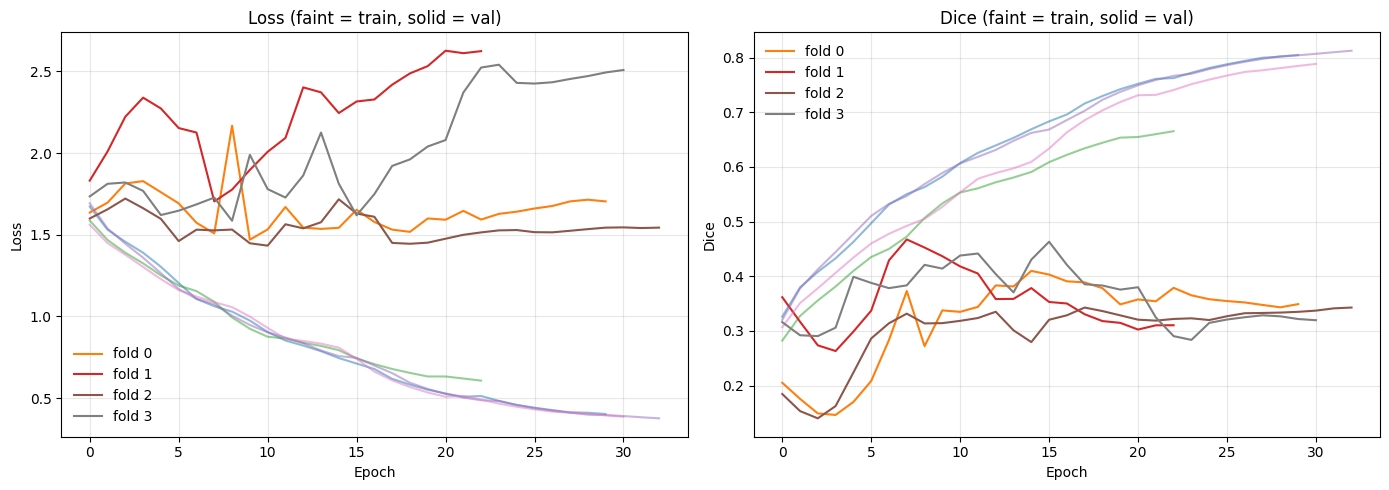

wrote ../outputs/figures/plots/stage05trainingCurves.png


In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fold, history in histories.items():
    label = "frozen split" if fold is None else f"fold {fold}"
    axes[0].plot(history.history["loss"], alpha=0.5)
    axes[0].plot(history.history["val_loss"], label=label)
    axes[1].plot(history.history["dice_coef"], alpha=0.5)
    axes[1].plot(history.history["val_dice_coef"], label=label)

axes[0].set_title("Loss (faint = train, solid = val)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[1].set_title("Dice (faint = train, solid = val)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dice")
for ax in axes:
    ax.legend(frameon=False); ax.grid(alpha=0.3)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, f"{ACTIVE_STAGE}trainingCurves.png")
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("wrote", out)